In [2]:
from src.data_processing.data_loader import MovieLensDataLoader
import pandas as pd
loader = MovieLensDataLoader()
data_dict = loader.load_data()

print("Dobijamo metapodatke iz API...")

await loader.letterboxd_data_async(max_concurrent_requests=100)

print(f"\n[Easy] Dobijeno ovoliko filmova: {len(loader.movie_data)}")

if loader.movie_data:
    print("\nPrimer prvog filma:")
    import pprint
    pprint.pprint(loader.movie_data[0])
    
    # Create dataframe from movie metadata
    df = pd.DataFrame(loader.movie_data)
    
    # Create genre features
    genre_features = loader.preprocess_movies()
    
    # Simply connect genre features with df
    df = pd.concat([df, genre_features], axis=1)
    
    # Clean up - remove unnecessary columns and reset index
    df = df.dropna().reset_index(drop=True)
    
    print("\nFinal dataframe shape:", df.shape)
    print("\nColumns:", list(df.columns))
    print("\nSample data:")
    print(df.head())
df.to_csv("data/processed/movie_metadata.csv", index=False)

INFO:src.data_processing.data_loader:Loading MovieLens dataset...
INFO:src.data_processing.data_loader:9742 films...


Dobijamo metapodatke iz API...


INFO:src.data_processing.data_loader:Successfully fetched from API: 9614 films.



[Easy] Dobijeno ovoliko filmova: 9614

Primer prvog filma:
{'cast': ['Tom Hanks',
          'Tim Allen',
          'Don Rickles',
          'Jim Varney',
          'Wallace Shawn'],
 'director': 'John Lasseter',
 'main_actor': 'Tom Hanks',
 'rating': 7.978,
 'runtime': 81,
 'title': 'Toy Story',
 'year': '1995'}

Final dataframe shape: (9580, 27)

Columns: ['title', 'year', 'cast', 'main_actor', 'director', 'rating', 'runtime', 'genre_(no genres listed)', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Children', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Fantasy', 'genre_Film-Noir', 'genre_Horror', 'genre_IMAX', 'genre_Musical', 'genre_Mystery', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller', 'genre_War', 'genre_Western']

Sample data:
                         title  year  \
0                    Toy Story  1995   
1                      Jumanji  1995   
2             Grumpier Old Men  1995   
3            Waiting to Exhale  1995   
4  Fa

In [3]:
import pandas as pd
movie_metadata = loader.movie_data
movie_metadata
df = pd.DataFrame(movie_metadata)

def cleaner(x):
    if isinstance(x, list):
        return [str.lower(i).replace(' ', '-') for i in x]
    elif isinstance(x, str):
        return str.lower(x).replace(' ', '-')
    return ""
df.head()
df['title_clean'] = df['title'].apply(cleaner)
df['main_actor_clean'] = df['main_actor'].apply(cleaner)
df['director_clean'] = df['director'].apply(cleaner)
df["rating"] = df["rating"].astype(float) / 2.0
df["cast_clean"] = df["cast"].apply(cleaner).apply(lambda x: [i for i in x if i])
a = loader.preprocess_movies()
df['genres_text'] = a.apply(lambda row: ' '.join([col.lower().replace(" ", "") for col in a.columns if row[col]]), 
    axis=1)
#df["genres_clean"] = df["genres"].apply(cleaner).apply(lambda x: [i for i in x if i])

df.head(10)


,title,year,cast,main_actor,director,rating,runtime,title_clean,main_actor_clean,director_clean,cast_clean,genres_text
0,Toy Story,1995,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...",Tom Hanks,John Lasseter,3.9890,81,toy-story,tom-hanks,john-lasseter,"[tom-hanks, tim-allen, don-rickles, jim-varney...",genre_adventure genre_animation genre_children...
1,Jumanji,1995,"[Robin Williams, Kirsten Dunst, Bradley Pierce...",Robin Williams,Joe Johnston,3.6235,104,jumanji,robin-williams,joe-johnston,"[robin-williams, kirsten-dunst, bradley-pierce...",genre_adventure genre_children genre_fantasy
2,Grumpier Old Men,1995,"[Walter Matthau, Jack Lemmon, Ann-Margret, Sop...",Walter Matthau,Howard Deutch,3.2390,101,grumpier-old-men,walter-matthau,howard-deutch,"[walter-matthau, jack-lemmon, ann-margret, sop...",genre_comedy genre_romance
3,Waiting to Exhale,1995,"[Whitney Houston, Angela Bassett, Loretta Devi...",Whitney Houston,Forest Whitaker,3.1215,127,waiting-to-exhale,whitney-houston,forest-whitaker,"[whitney-houston, angela-bassett, loretta-devi...",genre_comedy genre_drama genre_romance
4,Father of the Bride Part II,1995,"[Steve Martin, Diane Keaton, Martin Short, Kim...",Steve Martin,Charles Shyer,3.1370,106,father-of-the-bride-part-ii,steve-martin,charles-shyer,"[steve-martin, diane-keaton, martin-short, kim...",genre_comedy
5,Heat,1995,"[Al Pacino, Robert De Niro, Val Kilmer, Jon Vo...",Al Pacino,Michael Mann,3.9685,170,heat,al-pacino,michael-mann,"[al-pacino, robert-de-niro, val-kilmer, jon-vo...",genre_action genre_crime genre_thriller
6,Sabrina,1995,"[Harrison Ford, Julia Ormond, Greg Kinnear, Na...",Harrison Ford,Sydney Pollack,3.1060,127,sabrina,harrison-ford,sydney-pollack,"[harrison-ford, julia-ormond, greg-kinnear, na...",genre_comedy genre_romance
7,Tom and Huck,1995,"[Jonathan Taylor Thomas, Brad Renfro, Eric Sch...",Jonathan Taylor Thomas,Peter Hewitt,2.6500,97,tom-and-huck,jonathan-taylor-thomas,peter-hewitt,"[jonathan-taylor-thomas, brad-renfro, eric-sch...",genre_adventure genre_children
8,Sudden Death,1995,"[Jean-Claude Van Damme, Powers Boothe, Raymond...",Jean-Claude Van Damme,Peter Hyams,3.0170,111,sudden-death,jean-claude-van-damme,peter-hyams,"[jean-claude-van-damme, powers-boothe, raymond...",genre_action
9,GoldenEye,1995,"[Pierce Brosnan, Sean Bean, Izabella Scorupco,...",Pierce Brosnan,Martin Campbell,3.4510,130,goldeneye,pierce-brosnan,martin-campbell,"[pierce-brosnan, sean-bean, izabella-scorupco,...",genre_action genre_adventure genre_thriller


In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

median_runtime = df["runtime"].replace(0, np.nan).median()
df["runtime_filled"] = df["runtime"].replace({0: median_runtime, np.nan: median_runtime})

df["runtime_log"] = np.log1p(df["runtime_filled"])

scaler = MinMaxScaler()
df["runtime_scaled"] = scaler.fit_transform(df[["runtime_log"]])
df[["runtime", "runtime_filled", "runtime_log", "runtime_scaled"]].sort_values("runtime_scaled").head(50)

,runtime,runtime_filled,runtime_log,runtime_scaled
9602,2,2,1.098612,0.000000
6066,2,2,1.098612,0.000000
9308,3,3,1.386294,0.054575
7589,3,3,1.386294,0.054575
9487,4,4,1.609438,0.096907
9278,4,4,1.609438,0.096907
7862,4,4,1.609438,0.096907
7872,4,4,1.609438,0.096907
7847,5,5,1.791759,0.131495
7846,5,5,1.791759,0.131495


In [ ]:
df['main_actor_rating'] = df.groupby('main_actor_clean')['rating'].transform('mean')
median_rating_actor = df["main_actor_rating"].replace(0, np.nan).median()
df["main_actor_rating_filled"] = df["main_actor_rating"].replace({0: median_rating_actor, np.nan: median_rating_actor})

df["main_actor_rating_log"] = np.log1p(df["main_actor_rating_filled"])

scaler = MinMaxScaler()
df["main_actor_rating_scaled"] = scaler.fit_transform(df[["main_actor_rating_log"]])

,title,year,cast,main_actor,director,rating,runtime,title_clean,main_actor_clean,director_clean,cast_clean,genres_text,runtime_filled,runtime_log,runtime_scaled,main_actor_rating,main_actor_rating_filled,main_actor_rating_log,main_actor_rating_scaled
0,Toy Story,1995,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...",Tom Hanks,John Lasseter,3.9890,81,toy-story,tom-hanks,john-lasseter,"[tom-hanks, tim-allen, don-rickles, jim-varney...",genre_adventure genre_animation genre_children...,81,4.406719,0.627571,3.474429,3.474429,1.498379,0.834943
1,Jumanji,1995,"[Robin Williams, Kirsten Dunst, Bradley Pierce...",Robin Williams,Joe Johnston,3.6235,104,jumanji,robin-williams,joe-johnston,"[robin-williams, kirsten-dunst, bradley-pierce...",genre_adventure genre_children genre_fantasy,104,4.653960,0.674474,3.214224,3.214224,1.438466,0.774340
2,Grumpier Old Men,1995,"[Walter Matthau, Jack Lemmon, Ann-Margret, Sop...",Walter Matthau,Howard Deutch,3.2390,101,grumpier-old-men,walter-matthau,howard-deutch,"[walter-matthau, jack-lemmon, ann-margret, sop...",genre_comedy genre_romance,101,4.624973,0.668975,3.364313,3.364313,1.473461,0.809738
3,Waiting to Exhale,1995,"[Whitney Houston, Angela Bassett, Loretta Devi...",Whitney Houston,Forest Whitaker,3.1215,127,waiting-to-exhale,whitney-houston,forest-whitaker,"[whitney-houston, angela-bassett, loretta-devi...",genre_comedy genre_drama genre_romance,127,4.852030,0.712049,3.121500,3.121500,1.416217,0.751835
4,Father of the Bride Part II,1995,"[Steve Martin, Diane Keaton, Martin Short, Kim...",Steve Martin,Charles Shyer,3.1370,106,father-of-the-bride-part-ii,steve-martin,charles-shyer,"[steve-martin, diane-keaton, martin-short, kim...",genre_comedy,106,4.672829,0.678054,3.137433,3.137433,1.420076,0.755738
5,Heat,1995,"[Al Pacino, Robert De Niro, Val Kilmer, Jon Vo...",Al Pacino,Michael Mann,3.9685,170,heat,al-pacino,michael-mann,"[al-pacino, robert-de-niro, val-kilmer, jon-vo...",genre_action genre_crime genre_thriller,170,5.141664,0.766995,3.521640,3.521640,1.508875,0.845560
6,Sabrina,1995,"[Harrison Ford, Julia Ormond, Greg Kinnear, Na...",Harrison Ford,Sydney Pollack,3.1060,127,sabrina,harrison-ford,sydney-pollack,"[harrison-ford, julia-ormond, greg-kinnear, na...",genre_comedy genre_romance,127,4.852030,0.712049,3.313545,3.313545,1.461760,0.797903
7,Tom and Huck,1995,"[Jonathan Taylor Thomas, Brad Renfro, Eric Sch...",Jonathan Taylor Thomas,Peter Hewitt,2.6500,97,tom-and-huck,jonathan-taylor-thomas,peter-hewitt,"[jonathan-taylor-thomas, brad-renfro, eric-sch...",genre_adventure genre_children,97,4.584967,0.661386,2.861000,2.861000,1.350926,0.685792
8,Sudden Death,1995,"[Jean-Claude Van Damme, Powers Boothe, Raymond...",Jean-Claude Van Damme,Peter Hyams,3.0170,111,sudden-death,jean-claude-van-damme,peter-hyams,"[jean-claude-van-damme, powers-boothe, raymond...",genre_action,111,4.718499,0.686718,2.950000,2.950000,1.373716,0.708844
9,GoldenEye,1995,"[Pierce Brosnan, Sean Bean, Izabella Scorupco,...",Pierce Brosnan,Martin Campbell,3.4510,130,goldeneye,pierce-brosnan,martin-campbell,"[pierce-brosnan, sean-bean, izabella-scorupco,...",genre_action genre_adventure genre_thriller,130,4.875197,0.716444,3.083115,3.083115,1.406860,0.742370


In [11]:
df['director_rating'] = df.groupby('director_clean')['rating'].transform('mean')
median_rating_director = df["director_rating"].replace(0, np.nan).median()
df["director_rating_filled"] = df["director_rating"].replace({0: median_rating_director, np.nan: median_rating_director})

df["director_rating_log"] = np.log1p(df["director_rating_filled"])

scaler = MinMaxScaler()
df["director_rating_scaled"] = scaler.fit_transform(df[["director_rating_log"]])

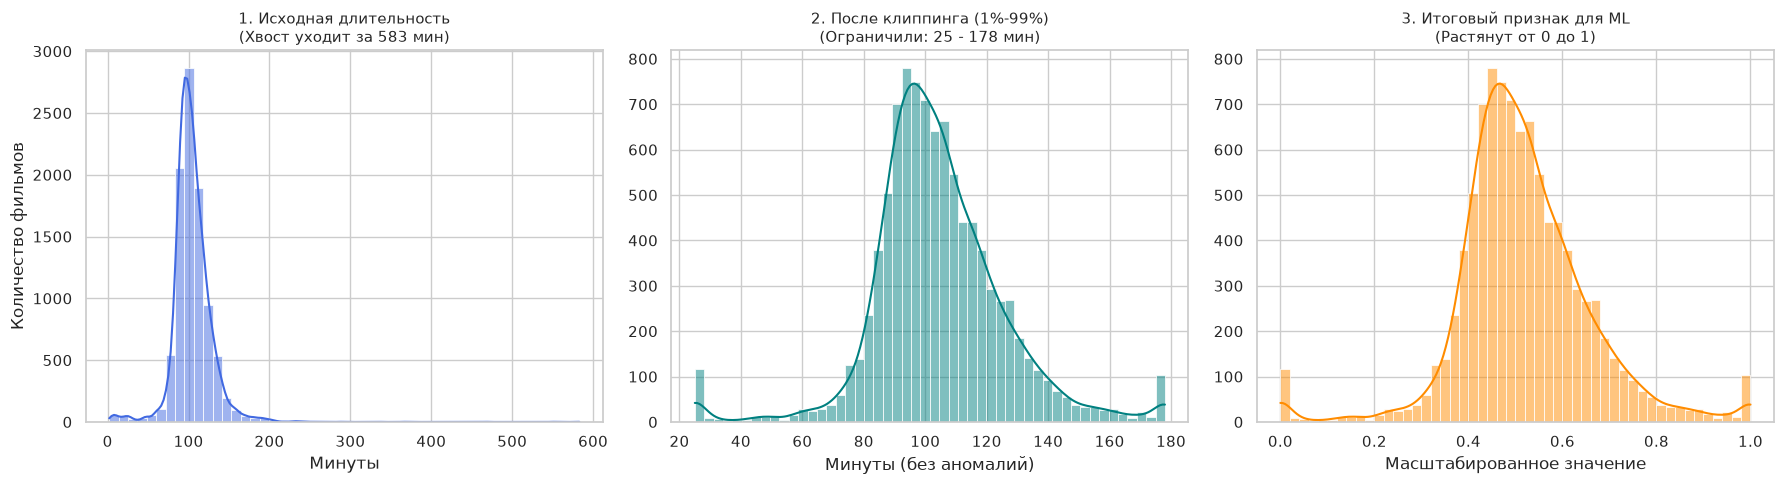

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# --- 1. Подготовка данных (Заполнение пропусков) ---
median_runtime = df["runtime"].replace(0, np.nan).median()
df["runtime_filled"] = df["runtime"].replace(
    {0: median_runtime, np.nan: median_runtime}
)

# --- 2. Клиппинг (Срезаем топ-1% экстремально длинных и коротких фильмов) ---
lower_bound = df["runtime_filled"].quantile(0.01)  # Отрежет скрытый мусор
upper_bound = df["runtime_filled"].quantile(0.99)  # Отрежет фильмы длиннее ~3.5 часов

df["runtime_clipped"] = df["runtime_filled"].clip(lower_bound, upper_bound)

# --- 3. Масштабирование в диапазон [0, 1] ---
scaler = MinMaxScaler()
df["runtime_scaled"] = scaler.fit_transform(df[["runtime_clipped"]])

# --- 4. Отрисовка новых графиков в Jupyter ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Исходные данные с хвостами
sns.histplot(
    df["runtime_filled"], bins=50, kde=True, ax=axes[0], color="royalblue"
)
axes[0].set_title(
    f"1. Исходная длительность\n(Хвост уходит за {int(df['runtime_filled'].max())} мин)",
    fontsize=11,
)
axes[0].set_xlabel("Минуты")
axes[0].set_ylabel("Количество фильмов")

# График 2: Данные после клиппинга
sns.histplot(
    df["runtime_clipped"], bins=50, kde=True, ax=axes[1], color="teal"
)
axes[1].set_title(
    f"2. После клиппинга (1%-99%)\n(Ограничили: {int(lower_bound)} - {int(upper_bound)} мин)",
    fontsize=11,
)
axes[1].set_xlabel("Минуты (без аномалий)")
axes[1].set_ylabel("")

# График 3: Финальный признак для Content-Based
sns.histplot(
    df["runtime_scaled"], bins=50, kde=True, ax=axes[2], color="darkorange"
)
axes[2].set_title(
    "3. Итоговый признак для ML\n(Растянут от 0 до 1)", fontsize=11
)
axes[2].set_xlabel("Масштабированное значение")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


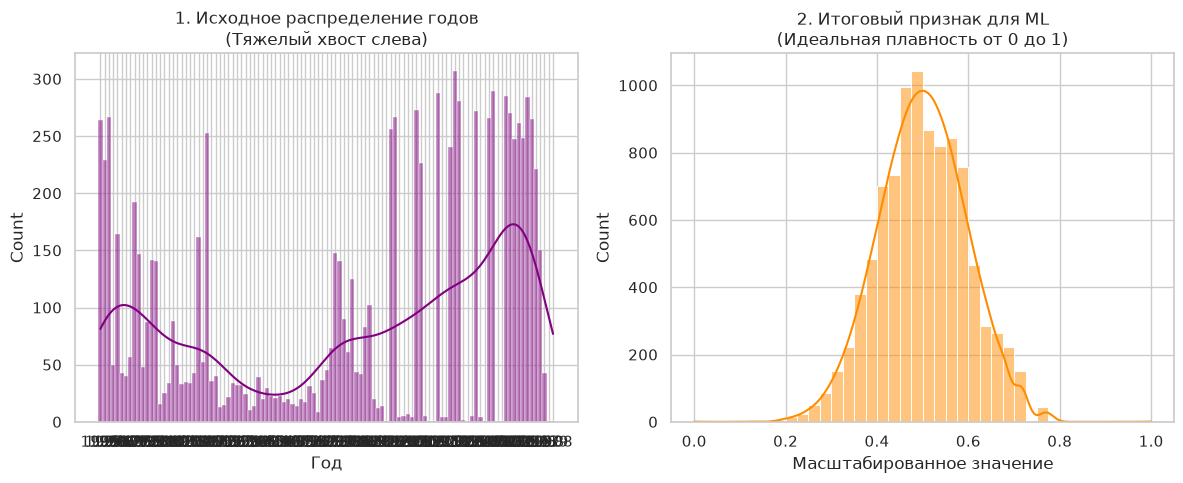

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer

# 1. Заполняем пропуски медианой (если они есть)
median_year = df["year"].astype(int).median()
df["year_filled"] = df["year"].fillna(median_year)

# 2. Применяем QuantileTransformer с нормальным распределением
# Обучаем трансформер
qt_year = QuantileTransformer(
    output_distribution="normal", n_quantiles=1000, random_state=42
)
year_transformed = qt_year.fit_transform(df[["year_filled"]])

# 3. Так как 'normal' выдает значения в пределах [-3, 3], сжимаем их в [0, 1] через MinMaxScaler
scaler_year = MinMaxScaler()
df["year_scaled"] = scaler_year.fit_transform(year_transformed)

# --- Визуализация ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["year_filled"], bins=40, kde=True, ax=axes[0], color="purple")
axes[0].set_title("1. Исходное распределение годов\n(Тяжелый хвост слева)")
axes[0].set_xlabel("Год")

sns.histplot(df["year_scaled"], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("2. Итоговый признак для ML\n(Идеальная плавность от 0 до 1)")
axes[1].set_xlabel("Масштабированное значение")

plt.tight_layout()
plt.show()

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
tfidf_main_actor = TfidfVectorizer()
tfidf_main_actor_matrix = tfidf_main_actor.fit_transform(df["main_actor_clean"].fillna(""))
#print(tfidf_main_actor_matrix)
tfidf_director = TfidfVectorizer()
tfidf_director_matrix = tfidf_director.fit_transform(df["director_clean"].fillna(""))
print(tfidf_director_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 19787 stored elements and shape (9614, 4584)>
  Coords	Values
  (0, 2043)	0.4567455414779516
  (0, 2375)	0.8895973866530931
  (1, 2035)	0.6040574385725648
  (1, 2047)	0.7969407825586241
  (2, 1837)	0.6101861970902829
  (2, 979)	0.7922580418528414
  (3, 1311)	0.7071067811865476
  (3, 4389)	0.7071067811865476
  (4, 678)	0.6093399583086574
  (4, 3825)	0.7929090838226055
  (5, 2823)	0.5605347137894416
  (5, 2631)	0.8281309284388483
  (6, 4028)	0.716278413874552
  (6, 3314)	0.6978146127857713
  (7, 3261)	0.5199218466062832
  (7, 1769)	0.854213833546093
  (8, 3261)	0.5497897539745482
  (8, 1864)	0.8353030745930519
  (9, 2667)	0.6085408330937965
  (9, 594)	0.7935225607741143
  (10, 3500)	0.651765982289797
  (10, 3443)	0.7584201370809033
  (11, 2784)	0.7260581432304967
  (11, 529)	0.6876333126373996
  (12, 3846)	0.651018654653256
  :	:
  (9600, 1925)	0.7071067811865476
  (9601, 709)	0.5736898166090151
  (9601, 4356)	0.81907264288286

In [9]:
df['cast_joined'] = df['cast_clean'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
tfidf_cast = TfidfVectorizer()
cast_matrix = tfidf_cast.fit_transform(df['cast_joined'])
print(cast_matrix)
df.head(10)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 96539 stored elements and shape (9614, 16642)>
  Coords	Values
  (0, 15031)	0.22023551143424572
  (0, 6129)	0.3143122160599555
  (0, 14976)	0.2638346223884337
  (0, 353)	0.2704473739345699
  (0, 3961)	0.2833188934217774
  (0, 12625)	0.41262253714202507
  (0, 7336)	0.25328941086747675
  (0, 15492)	0.40661634478566305
  (0, 15779)	0.34354924691015154
  (0, 13700)	0.3345268961019164
  (1, 12736)	0.27316810572604416
  (1, 16024)	0.2501399185819387
  (1, 8058)	0.33426564050955754
  (1, 4153)	0.33917294059616354
  (1, 1942)	0.3195365620348443
  (1, 11895)	0.3207095722600397
  (1, 1805)	0.34860677434573195
  (1, 6797)	0.3183905199652787
  (1, 7416)	0.27271284562616604
  (1, 6832)	0.36579729137688993
  (2, 15790)	0.2755210773305636
  (2, 9813)	0.3354962273230755
  (2, 7105)	0.22427901367461456
  (2, 8738)	0.3333898261546536
  (2, 567)	0.2725768868474217
  :	:
  (9611, 8612)	0.3027473717939342
  (9611, 6994)	0.3207078246461304
  (961

,title,year,cast,main_actor,director,rating,runtime,title_clean,main_actor_clean,director_clean,...,runtime_log,runtime_scaled,main_actor_rating,main_actor_rating_filled,main_actor_rating_log,main_actor_rating_scaled,runtime_clipped,year_filled,year_scaled,cast_joined
0,Toy Story,1995,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...",Tom Hanks,John Lasseter,3.9890,81,toy-story,tom-hanks,john-lasseter,...,4.406719,0.366013,3.474429,3.474429,1.498379,0.834943,81,1995,0.472484,tom-hanks tim-allen don-rickles jim-varney wal...
1,Jumanji,1995,"[Robin Williams, Kirsten Dunst, Bradley Pierce...",Robin Williams,Joe Johnston,3.6235,104,jumanji,robin-williams,joe-johnston,...,4.653960,0.516340,3.214224,3.214224,1.438466,0.774340,104,1995,0.472484,robin-williams kirsten-dunst bradley-pierce bo...
2,Grumpier Old Men,1995,"[Walter Matthau, Jack Lemmon, Ann-Margret, Sop...",Walter Matthau,Howard Deutch,3.2390,101,grumpier-old-men,walter-matthau,howard-deutch,...,4.624973,0.496732,3.364313,3.364313,1.473461,0.809738,101,1995,0.472484,walter-matthau jack-lemmon ann-margret sophia-...
3,Waiting to Exhale,1995,"[Whitney Houston, Angela Bassett, Loretta Devi...",Whitney Houston,Forest Whitaker,3.1215,127,waiting-to-exhale,whitney-houston,forest-whitaker,...,4.852030,0.666667,3.121500,3.121500,1.416217,0.751835,127,1995,0.472484,whitney-houston angela-bassett loretta-devine ...
4,Father of the Bride Part II,1995,"[Steve Martin, Diane Keaton, Martin Short, Kim...",Steve Martin,Charles Shyer,3.1370,106,father-of-the-bride-part-ii,steve-martin,charles-shyer,...,4.672829,0.529412,3.137433,3.137433,1.420076,0.755738,106,1995,0.472484,steve-martin diane-keaton martin-short kimberl...
5,Heat,1995,"[Al Pacino, Robert De Niro, Val Kilmer, Jon Vo...",Al Pacino,Michael Mann,3.9685,170,heat,al-pacino,michael-mann,...,5.141664,0.947712,3.521640,3.521640,1.508875,0.845560,170,1995,0.472484,al-pacino robert-de-niro val-kilmer jon-voight...
6,Sabrina,1995,"[Harrison Ford, Julia Ormond, Greg Kinnear, Na...",Harrison Ford,Sydney Pollack,3.1060,127,sabrina,harrison-ford,sydney-pollack,...,4.852030,0.666667,3.313545,3.313545,1.461760,0.797903,127,1995,0.472484,harrison-ford julia-ormond greg-kinnear nancy-...
7,Tom and Huck,1995,"[Jonathan Taylor Thomas, Brad Renfro, Eric Sch...",Jonathan Taylor Thomas,Peter Hewitt,2.6500,97,tom-and-huck,jonathan-taylor-thomas,peter-hewitt,...,4.584967,0.470588,2.861000,2.861000,1.350926,0.685792,97,1995,0.472484,jonathan-taylor-thomas brad-renfro eric-schwei...
8,Sudden Death,1995,"[Jean-Claude Van Damme, Powers Boothe, Raymond...",Jean-Claude Van Damme,Peter Hyams,3.0170,111,sudden-death,jean-claude-van-damme,peter-hyams,...,4.718499,0.562092,2.950000,2.950000,1.373716,0.708844,111,1995,0.472484,jean-claude-van-damme powers-boothe raymond-j....
9,GoldenEye,1995,"[Pierce Brosnan, Sean Bean, Izabella Scorupco,...",Pierce Brosnan,Martin Campbell,3.4510,130,goldeneye,pierce-brosnan,martin-campbell,...,4.875197,0.686275,3.083115,3.083115,1.406860,0.742370,130,1995,0.472484,pierce-brosnan sean-bean izabella-scorupco fam...


In [10]:
from scipy.sparse import csr_matrix
numerical_features = df[['runtime_scaled', 'year_scaled', 'main_actor_rating_scaled']].values
numerical_matrix = csr_matrix(numerical_features)
print(numerical_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 28731 stored elements and shape (9614, 3)>
  Coords	Values
  (0, 0)	0.36601307189542487
  (0, 1)	0.4724835201354867
  (0, 2)	0.8349430142734388
  (1, 0)	0.5163398692810458
  (1, 1)	0.4724835201354867
  (1, 2)	0.7743396795463685
  (2, 0)	0.49673202614379086
  (2, 1)	0.4724835201354867
  (2, 2)	0.8097379881329455
  (3, 0)	0.6666666666666667
  (3, 1)	0.4724835201354867
  (3, 2)	0.7518350551595866
  (4, 0)	0.5294117647058824
  (4, 1)	0.4724835201354867
  (4, 2)	0.7557379567832644
  (5, 0)	0.9477124183006537
  (5, 1)	0.4724835201354867
  (5, 2)	0.8455600372277529
  (6, 0)	0.6666666666666667
  (6, 1)	0.4724835201354867
  (6, 2)	0.7979027039347449
  (7, 0)	0.47058823529411764
  (7, 1)	0.4724835201354867
  (7, 2)	0.6857919588313645
  (8, 0)	0.5620915032679739
  :	:
  (9605, 2)	0.9293203817859573
  (9606, 0)	0.5620915032679739
  (9606, 1)	0.6315985229319955
  (9606, 2)	0.806415318634944
  (9607, 0)	0.4836601307189543
  (9607, 1)	0.65